In [ ]:
import tensorflow as tf

In [ ]:
vgg16 = tf.keras.applications.VGG16(include_top=True)

553476096/553467096 [==============================] - 6s 0us/step


In [ ]:
vgg16.input_shape

(None, 224, 224, 3)

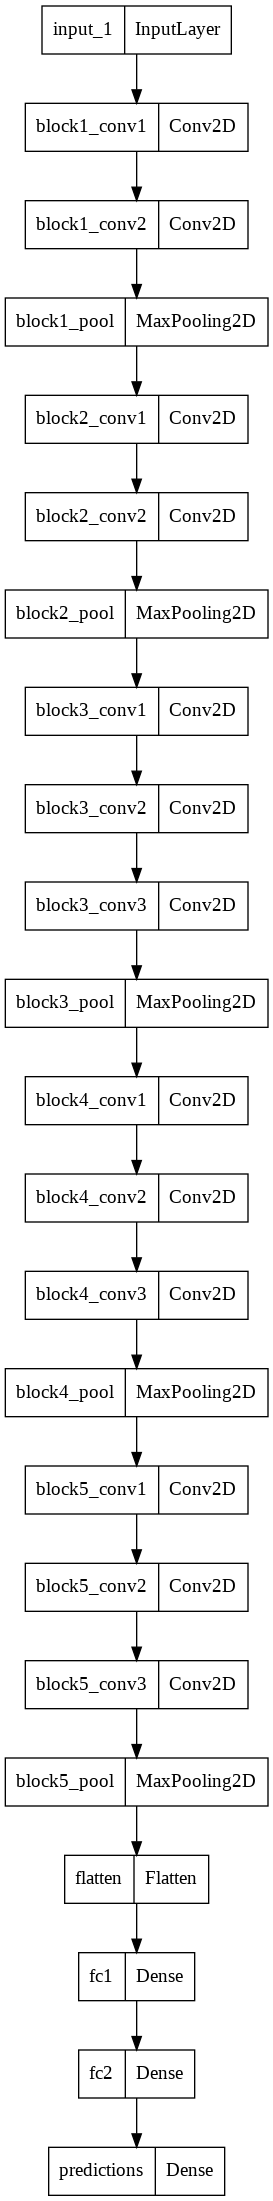

In [ ]:
tf.keras.utils.plot_model(vgg16)

In [ ]:
vgg16.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [ ]:
modelS = vgg16.to_json()

In [ ]:
modelS

'{"class_name": "Functional", "config": {"name": "vgg16", "layers": [{"class_name": "InputLayer", "config": {"batch_input_shape": [null, 224, 224, 3], "dtype": "float32", "sparse": false, "ragged": false, "name": "input_1"}, "name": "input_1", "inbound_nodes": []}, {"class_name": "Conv2D", "config": {"name": "block1_conv1", "trainable": true, "dtype": "float32", "filters": 64, "kernel_size": [3, 3], "strides": [1, 1], "padding": "same", "data_format": "channels_last", "dilation_rate": [1, 1], "groups": 1, "activation": "relu", "use_bias": true, "kernel_initializer": {"class_name": "GlorotUniform", "config": {"seed": null}}, "bias_initializer": {"class_name": "Zeros", "config": {}}, "kernel_regularizer": null, "bias_regularizer": null, "activity_regularizer": null, "kernel_constraint": null, "bias_constraint": null}, "name": "block1_conv1", "inbound_nodes": [[["input_1", 0, 0, {}]]]}, {"class_name": "Conv2D", "config": {"name": "block1_conv2", "trainable": true, "dtype": "float32", "fil

In [ ]:
for layer in vgg16.layers:
  print(f"Name: {layer.name}")
  print(f"\t Inp: {layer.input_shape}")
  print(f"\t Out: {layer.output_shape}")
  print(f"\t Train: {layer.trainable}")
  if "conv" in layer.name:
    print(f"\t Kernel Size: {layer.kernel_size}")
    print(f"\t Stride Size: {layer.strides}")
  if 'pool' in layer.name: 
    print(f"\t Pool Size: {layer.pool_size}")
    print(f"\t Stride Size: {layer.strides}")

Name: input_2
	 Inp: [(None, 224, 224, 3)]
	 Out: [(None, 224, 224, 3)]
	 Train: True
Name: block1_conv1
	 Inp: (None, 224, 224, 3)
	 Out: (None, 224, 224, 64)
	 Train: True
	 Kernel Size: (3, 3)
	 Stride Size: (1, 1)
Name: block1_conv2
	 Inp: (None, 224, 224, 64)
	 Out: (None, 224, 224, 64)
	 Train: True
	 Kernel Size: (3, 3)
	 Stride Size: (1, 1)
Name: block1_pool
	 Inp: (None, 224, 224, 64)
	 Out: (None, 112, 112, 64)
	 Train: True
	 Pool Size: (2, 2)
	 Stride Size: (2, 2)
Name: block2_conv1
	 Inp: (None, 112, 112, 64)
	 Out: (None, 112, 112, 128)
	 Train: True
	 Kernel Size: (3, 3)
	 Stride Size: (1, 1)
Name: block2_conv2
	 Inp: (None, 112, 112, 128)
	 Out: (None, 112, 112, 128)
	 Train: True
	 Kernel Size: (3, 3)
	 Stride Size: (1, 1)
Name: block2_pool
	 Inp: (None, 112, 112, 128)
	 Out: (None, 56, 56, 128)
	 Train: True
	 Pool Size: (2, 2)
	 Stride Size: (2, 2)
Name: block3_conv1
	 Inp: (None, 56, 56, 128)
	 Out: (None, 56, 56, 256)
	 Train: True
	 Kernel Size: (3, 3)
	 Stride Si

In [ ]:

import numpy as np
result_array = np.zeros(shape=(1, 1000))
result_array[0] = 1

In [ ]:
tf.keras.applications.vgg16.decode_predictions(result_array)

49152/35363 [=========================================] - 0s 0us/step


[[('n15075141', 'toilet_tissue', 1.0),
  ('n02319095', 'sea_urchin', 1.0),
  ('n02395406', 'hog', 1.0),
  ('n02391049', 'zebra', 1.0),
  ('n02389026', 'sorrel', 1.0)]]

In [ ]:
! cat /root/.keras/models/imagenet_class_index.json

{"0": ["n01440764", "tench"], "1": ["n01443537", "goldfish"], "2": ["n01484850", "great_white_shark"], "3": ["n01491361", "tiger_shark"], "4": ["n01494475", "hammerhead"], "5": ["n01496331", "electric_ray"], "6": ["n01498041", "stingray"], "7": ["n01514668", "cock"], "8": ["n01514859", "hen"], "9": ["n01518878", "ostrich"], "10": ["n01530575", "brambling"], "11": ["n01531178", "goldfinch"], "12": ["n01532829", "house_finch"], "13": ["n01534433", "junco"], "14": ["n01537544", "indigo_bunting"], "15": ["n01558993", "robin"], "16": ["n01560419", "bulbul"], "17": ["n01580077", "jay"], "18": ["n01582220", "magpie"], "19": ["n01592084", "chickadee"], "20": ["n01601694", "water_ouzel"], "21": ["n01608432", "kite"], "22": ["n01614925", "bald_eagle"], "23": ["n01616318", "vulture"], "24": ["n01622779", "great_grey_owl"], "25": ["n01629819", "European_fire_salamander"], "26": ["n01630670", "common_newt"], "27": ["n01631663", "eft"], "28": ["n01632458", "spotted_salamander"], "29": ["n01632777", 

In [ ]:
with open("/root/.keras/models/imagenet_class_index.json") as j:
  labels = j.read()

In [ ]:
labels

'{"0": ["n01440764", "tench"], "1": ["n01443537", "goldfish"], "2": ["n01484850", "great_white_shark"], "3": ["n01491361", "tiger_shark"], "4": ["n01494475", "hammerhead"], "5": ["n01496331", "electric_ray"], "6": ["n01498041", "stingray"], "7": ["n01514668", "cock"], "8": ["n01514859", "hen"], "9": ["n01518878", "ostrich"], "10": ["n01530575", "brambling"], "11": ["n01531178", "goldfinch"], "12": ["n01532829", "house_finch"], "13": ["n01534433", "junco"], "14": ["n01537544", "indigo_bunting"], "15": ["n01558993", "robin"], "16": ["n01560419", "bulbul"], "17": ["n01580077", "jay"], "18": ["n01582220", "magpie"], "19": ["n01592084", "chickadee"], "20": ["n01601694", "water_ouzel"], "21": ["n01608432", "kite"], "22": ["n01614925", "bald_eagle"], "23": ["n01616318", "vulture"], "24": ["n01622779", "great_grey_owl"], "25": ["n01629819", "European_fire_salamander"], "26": ["n01630670", "common_newt"], "27": ["n01631663", "eft"], "28": ["n01632458", "spotted_salamander"], "29": ["n01632777",

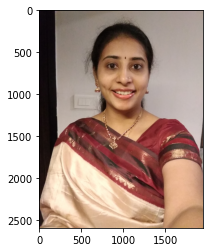

In [21]:
import cv2
import matplotlib.pyplot as plt
image = '/content/IMG_20181028_065756.jpg'
image = cv2.cvtColor(cv2.imread(image), cv2.COLOR_BGR2RGB)
plt.imshow(image)
#
image = cv2.resize(image, (224, 224))
image = tf.keras.applications.vgg16.preprocess_input(image)
image = np.expand_dims(image, axis=0)

In [22]:
image.shape
dr = vgg16.predict(image)

In [23]:
tf.keras.applications.vgg16.decode_predictions(dr, top=10)

[[('n03617480', 'kimono', 0.49523702),
  ('n03877472', 'pajama', 0.19517815),
  ('n04325704', 'stole', 0.05684484),
  ('n03450230', 'gown', 0.04984284),
  ('n03866082', 'overskirt', 0.02102423),
  ('n03534580', 'hoopskirt', 0.013996177),
  ('n04525038', 'velvet', 0.011945489),
  ('n10148035', 'groom', 0.011080714),
  ('n04532106', 'vestment', 0.01002429),
  ('n04479046', 'trench_coat', 0.0085071875)]]